# PowerCo Customer Churn Analysis

## Task 3: Exploratory Data Analysis and Data Cleaning

### Objective
The goal of this analysis is to investigate whether price sensitivity
is an important factor influencing customer churn at PowerCo.

We will:
- Load and understand the client datasets
- Inspect data types and structure
- Check data quality
- Calculate descriptive statistics
- Analyze distributions
- Create visualizations
- Identify initial patterns related to customer churn

## 1. Import Required Libraries

We will use:
- **Pandas** for loading and manipulating tabular data
- **NumPy** for numerical operations
- **Matplotlib** for visualization
- **Seaborn** for statistical visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Datasets

PowerCo has provided two main datasets for this stage:

- **Client data** — historical customer information
- **Price data** — historical pricing information

We will load both CSV files into Pandas DataFrames so that we can inspect and analyze them.

In [2]:
client_df = pd.read_csv("../02_Data/client_data.csv")
price_df = pd.read_csv("../02_Data/price_data.csv")

## 3. Initial Data Inspection

Before performing any analysis, we need to understand the basic structure of the datasets.

We will first check:
- The number of rows and columns
- The first few records
- The column names

In [3]:
print("Client Data Shape:", client_df.shape)
print("Price Data Shape:", price_df.shape)

Client Data Shape: (14606, 26)
Price Data Shape: (193002, 8)


## 4. Preview the Datasets

Before analyzing the variables, we need to see what the actual records look like.

We will inspect the first few rows of each dataset to understand:
- What each column looks like
- How the values are represented
- Whether there are obvious formatting or data-quality issues

In [4]:
client_df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


In [5]:
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


## 5. Check Data Types

Before performing statistical analysis, we need to understand how Pandas
has interpreted each variable.

This is important because:
- Numerical variables should be stored as numeric types.
- Dates should ideally be stored as datetime values.
- Categorical variables are generally stored as object/string types.
- Incorrect data types can cause errors or misleading analysis.

In [6]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [7]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


## 6. Descriptive Statistics

Descriptive statistics help us understand the numerical variables in the
datasets.

We will examine:
- Count of observations
- Mean
- Standard deviation
- Minimum and maximum values
- Quartiles

This helps us identify the scale, variation, and potential unusual values
before creating visualizations.

In [8]:
client_df.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


## 7. Descriptive Statistics — Price Data

The price dataset contains historical pricing information recorded over
time.

We will use descriptive statistics to understand the typical values and
variation of the variable and fixed pricing components.

In [9]:
price_df.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


## 8. Churn Distribution

The `churn` column is our target variable

It indicates whether a customer:
- **0** → did not churn
- **1** → churned

Before analyzing other variables, we need to understand how the target
classes are distributed.

This is important because a large difference between the two classes
can create class imbalance and affect how we evaluate a predictive model.

In [10]:
client_df["churn"].value_counts()

churn
0    13187
1     1419
Name: count, dtype: int64

In [11]:
client_df["churn"].value_counts(normalize=True) * 100

churn
0    90.284814
1     9.715186
Name: proportion, dtype: float64

## 9. Visualizing Churn Distribution

A count plot allows us to visually compare the number of customers who
churned with those who remained.

This makes the class imbalance easier to see than numerical percentages
alone.

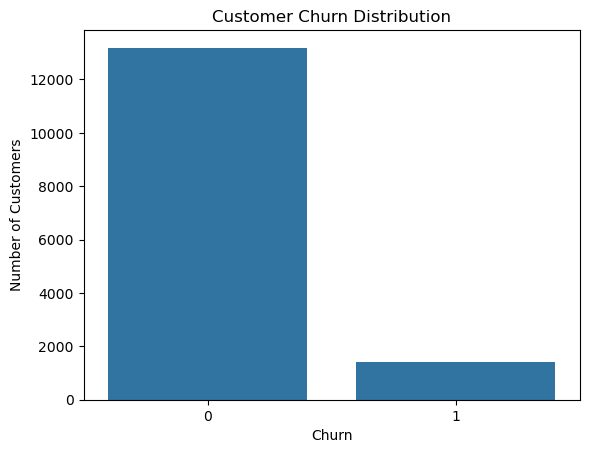

In [12]:
sns.countplot(data=client_df, x="churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

## 10. Distribution of Numerical Variables

We will now examine how the numerical variables are distributed.

Distribution plots help us identify:
- The typical range of values
- Skewness
- Possible outliers
- Variables with very concentrated or widely spread values

We will first identify the numerical columns and then visualize their
distributions.

In [13]:
numeric_columns = client_df.select_dtypes(include=np.number).columns

numeric_columns

Index(['cons_12m', 'cons_gas_12m', 'cons_last_month', 'forecast_cons_12m',
       'forecast_cons_year', 'forecast_discount_energy',
       'forecast_meter_rent_12m', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'imp_cons',
       'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act',
       'net_margin', 'num_years_antig', 'pow_max', 'churn'],
      dtype='object')

## 11. Numerical Features for Distribution Analysis

The `churn` column is our target variable, so we have already analyzed it
separately.

For the next stage, we will examine the distributions of the numerical
customer features that may help explain differences between customers.

In [14]:
numeric_features = client_df.select_dtypes(include=np.number).columns.drop("churn")

numeric_features

Index(['cons_12m', 'cons_gas_12m', 'cons_last_month', 'forecast_cons_12m',
       'forecast_cons_year', 'forecast_discount_energy',
       'forecast_meter_rent_12m', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'imp_cons',
       'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act',
       'net_margin', 'num_years_antig', 'pow_max'],
      dtype='object')

## 12. Distribution of Numerical Features

We will visualize the distributions of the numerical customer features
using histograms.

Histograms help us identify:
- Where most observations are concentrated
- Whether a variable is symmetric or skewed
- Potential extreme values
- Differences in the scale of variables

Because the variables have different units and ranges, each feature is
shown separately.

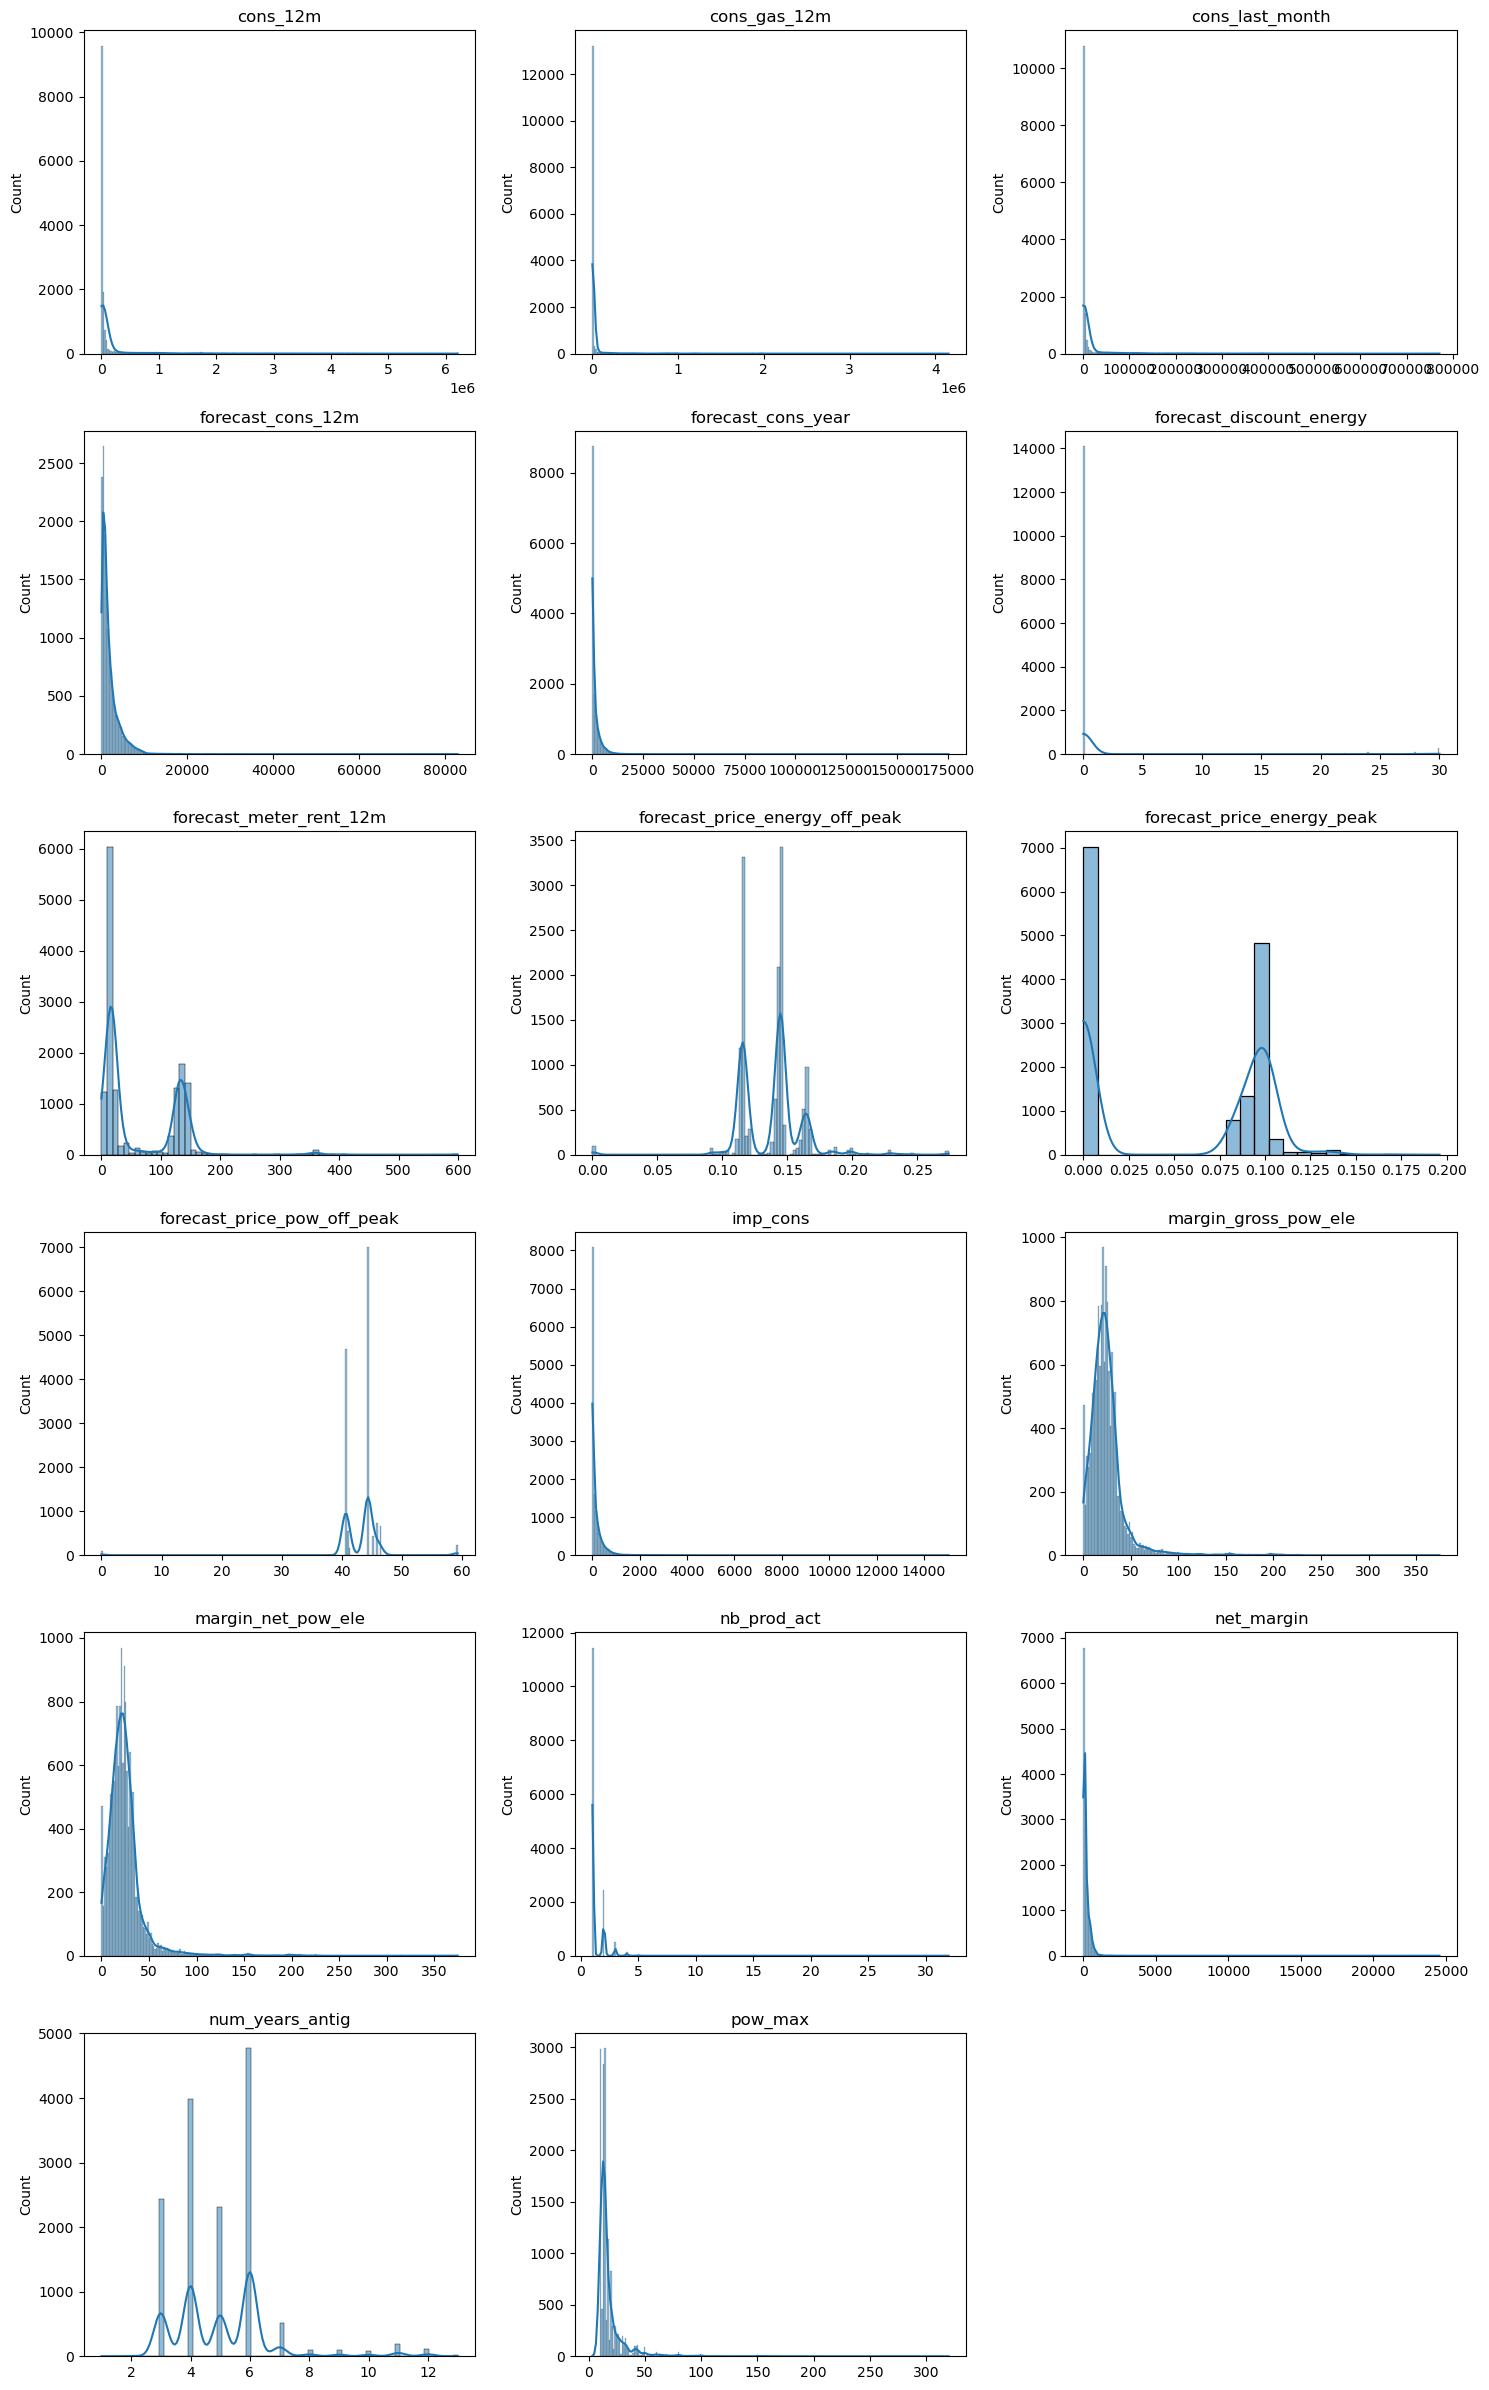

In [15]:
fig, axes = plt.subplots(6, 3, figsize=(15, 24))

for ax, column in zip(axes.flatten(), numeric_features):
    sns.histplot(client_df[column], kde=True, ax=ax)
    ax.set_title(column)
    ax.set_xlabel("")
    
# Hide unused subplot
for ax in axes.flatten()[len(numeric_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## 13. Checking for Potential Extreme Values

The distribution plots show that several numerical variables are strongly
right-skewed and contain potentially extreme observations.

We will examine the minimum and maximum values of each numerical feature
to determine whether these observations require further investigation.

Extreme values will not be removed automatically because they may represent
legitimate customers rather than data errors.

In [16]:
summary = client_df[numeric_features].agg(["min", "max"]).T

summary

,min,max
cons_12m,0.0,6.207104e+06
cons_gas_12m,0.0,4.154590e+06
cons_last_month,0.0,7.712030e+05
forecast_cons_12m,0.0,8.290283e+04
forecast_cons_year,0.0,1.753750e+05
forecast_discount_energy,0.0,3.000000e+01
forecast_meter_rent_12m,0.0,5.993100e+02
forecast_price_energy_off_peak,0.0,2.739630e-01
forecast_price_energy_peak,0.0,1.959750e-01
forecast_price_pow_off_peak,0.0,5.926638e+01


## 13. Checking Missing and Placeholder Values

The initial inspection showed no standard null values in the dataset.
However, some categorical variables may contain placeholder values such
as `"MISSING"`.

We will check both:
- Standard missing values (`NaN`)
- Explicit placeholder values such as `"MISSING"`

This helps us distinguish between genuinely complete data and values that
have been encoded as text.

In [17]:
client_df.isnull().sum()

id                                0
channel_sales                     0
cons_12m                          0
cons_gas_12m                      0
cons_last_month                   0
date_activ                        0
date_end                          0
date_modif_prod                   0
date_renewal                      0
forecast_cons_12m                 0
forecast_cons_year                0
forecast_discount_energy          0
forecast_meter_rent_12m           0
forecast_price_energy_off_peak    0
forecast_price_energy_peak        0
forecast_price_pow_off_peak       0
has_gas                           0
imp_cons                          0
margin_gross_pow_ele              0
margin_net_pow_ele                0
nb_prod_act                       0
net_margin                        0
num_years_antig                   0
origin_up                         0
pow_max                           0
churn                             0
dtype: int64

## 14. Checking Placeholder Values

Although the dataset contains no standard null values, some categorical
variables may use text such as `"MISSING"` to represent unavailable
information.

We will identify how frequently this placeholder occurs.

In [18]:
(client_df == "MISSING").sum()

id                                   0
channel_sales                     3725
cons_12m                             0
cons_gas_12m                         0
cons_last_month                      0
date_activ                           0
date_end                             0
date_modif_prod                      0
date_renewal                         0
forecast_cons_12m                    0
forecast_cons_year                   0
forecast_discount_energy             0
forecast_meter_rent_12m              0
forecast_price_energy_off_peak       0
forecast_price_energy_peak           0
forecast_price_pow_off_peak          0
has_gas                              0
imp_cons                             0
margin_gross_pow_ele                 0
margin_net_pow_ele                   0
nb_prod_act                          0
net_margin                           0
num_years_antig                      0
origin_up                           64
pow_max                              0
churn                    

## 15. Exploring Categorical Variables

Numerical variables describe quantities such as consumption and margins.
Categorical variables describe groups or categories such as sales channel,
gas availability, and customer origin.

We will inspect the unique values and their frequencies to understand the
categorical variables and identify any unusual or placeholder categories.

In [19]:
categorical_columns = client_df.select_dtypes(include="object").columns

categorical_columns

Index(['id', 'channel_sales', 'date_activ', 'date_end', 'date_modif_prod',
       'date_renewal', 'has_gas', 'origin_up'],
      dtype='object')

## 16. Distribution of Sales Channels

`channel_sales` represents the sales channel through which customers were
acquired.

We will examine the frequency of each category, including any `"MISSING"`
placeholder values identified earlier.

In [20]:
client_df["channel_sales"].value_counts()

channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
MISSING                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64

## 17. Distribution of Gas Availability

The `has_gas` variable indicates whether a customer has a gas service
associated with their account.

We will examine the frequency of each category to understand the
composition of the customer base.

In [21]:
client_df["has_gas"].value_counts()

has_gas
f    11955
t     2651
Name: count, dtype: int64

## 18. Distribution of Customer Origin

The `origin_up` variable represents information about the customer's
origin or acquisition source.

We will examine the frequency of each category to understand how customers
are distributed across the available origins.

In [22]:
client_df["origin_up"].value_counts()

origin_up
lxidpiddsbxsbosboudacockeimpuepw    7097
kamkkxfxxuwbdslkwifmmcsiusiuosws    4294
ldkssxwpmemidmecebumciepifcamkci    3148
MISSING                               64
usapbepcfoloekilkwsdiboslwaxobdp       2
ewxeelcelemmiwuafmddpobolfuxioce       1
Name: count, dtype: int64

### Interpretation

The `origin_up` variable contains three dominant customer-origin categories,
while a small number of customers belong to rare categories.

There are also 64 `"MISSING"` values. Since these are relatively few
compared with the total dataset, we will retain them for now rather than
dropping the corresponding customers.

The meaning of each encoded category will be verified using the Data
Description before any further processing.

## 19. Inspecting Date Variables

The dataset contains several columns representing important customer
dates, such as activation, renewal, modification, and contract end dates.

These columns are currently stored as `object` data types. We will inspect
their values before converting them to datetime format.

In [23]:
date_columns = [
    "date_activ",
    "date_end",
    "date_modif_prod",
    "date_renewal"
]

client_df[date_columns].head()

,date_activ,date_end,date_modif_prod,date_renewal
0,2013-06-15,2016-06-15,2015-11-01,2015-06-23
1,2009-08-21,2016-08-30,2009-08-21,2015-08-31
2,2010-04-16,2016-04-16,2010-04-16,2015-04-17
3,2010-03-30,2016-03-30,2010-03-30,2015-03-31
4,2010-01-13,2016-03-07,2010-01-13,2015-03-09


## 20. Converting Date Columns to Datetime

The date columns are currently stored as `object` values even though they
represent dates.

We will convert them to Pandas datetime format so that we can:
- Perform date calculations
- Calculate time differences
- Create useful time-based features later

In [24]:
for column in date_columns:
    client_df[column] = pd.to_datetime(client_df[column])

In [25]:
client_df[date_columns].dtypes

date_activ         datetime64[ns]
date_end           datetime64[ns]
date_modif_prod    datetime64[ns]
date_renewal       datetime64[ns]
dtype: object

## 21. Converting the Price Date

The price dataset contains a `price_date` column that represents the date
when the pricing information was recorded.

Like the customer date columns, it is currently stored as an object.
We will convert it to datetime format so that the pricing data can be
analyzed correctly over time.

In [26]:
price_df["price_date"] = pd.to_datetime(price_df["price_date"])

In [27]:
price_df["price_date"].dtype

dtype('<M8[ns]')

## 22. Inspecting the Price Dataset

The price dataset contains historical pricing information for customers
over time.

We will first examine its categorical and identifier columns to understand
how the pricing records are organized before analyzing the numerical
pricing variables.

In [28]:
price_df.select_dtypes(include="object").columns

Index(['id'], dtype='object')

## 23. Understanding Price Data Structure

The price dataset contains multiple pricing records for customers over time.

The `id` column identifies the customer, while `price_date` identifies
when the pricing information was recorded.

We will check:
- The number of unique customers
- The date range covered by the pricing data

This helps us understand the granularity and time span of the dataset.

In [29]:
price_df["id"].nunique()

16096

In [30]:
print("Earliest price date:", price_df["price_date"].min())
print("Latest price date:", price_df["price_date"].max())

Earliest price date: 2015-01-01 00:00:00
Latest price date: 2015-12-01 00:00:00


## 24. Identifying Pricing Variables

The price dataset contains several numerical variables representing
different pricing components.

We will identify these numerical columns before analyzing their
distributions and relationships.

In [31]:
price_numeric_columns = price_df.select_dtypes(include=np.number).columns

price_numeric_columns

Index(['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var',
       'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix'],
      dtype='object')

## 25. Distribution of Pricing Variables

We will examine the distributions of the six pricing variables using
histograms.

This will help us understand:
- The typical range of pricing values
- How much the prices vary
- Whether the variables are skewed
- Whether there are unusual or extreme values

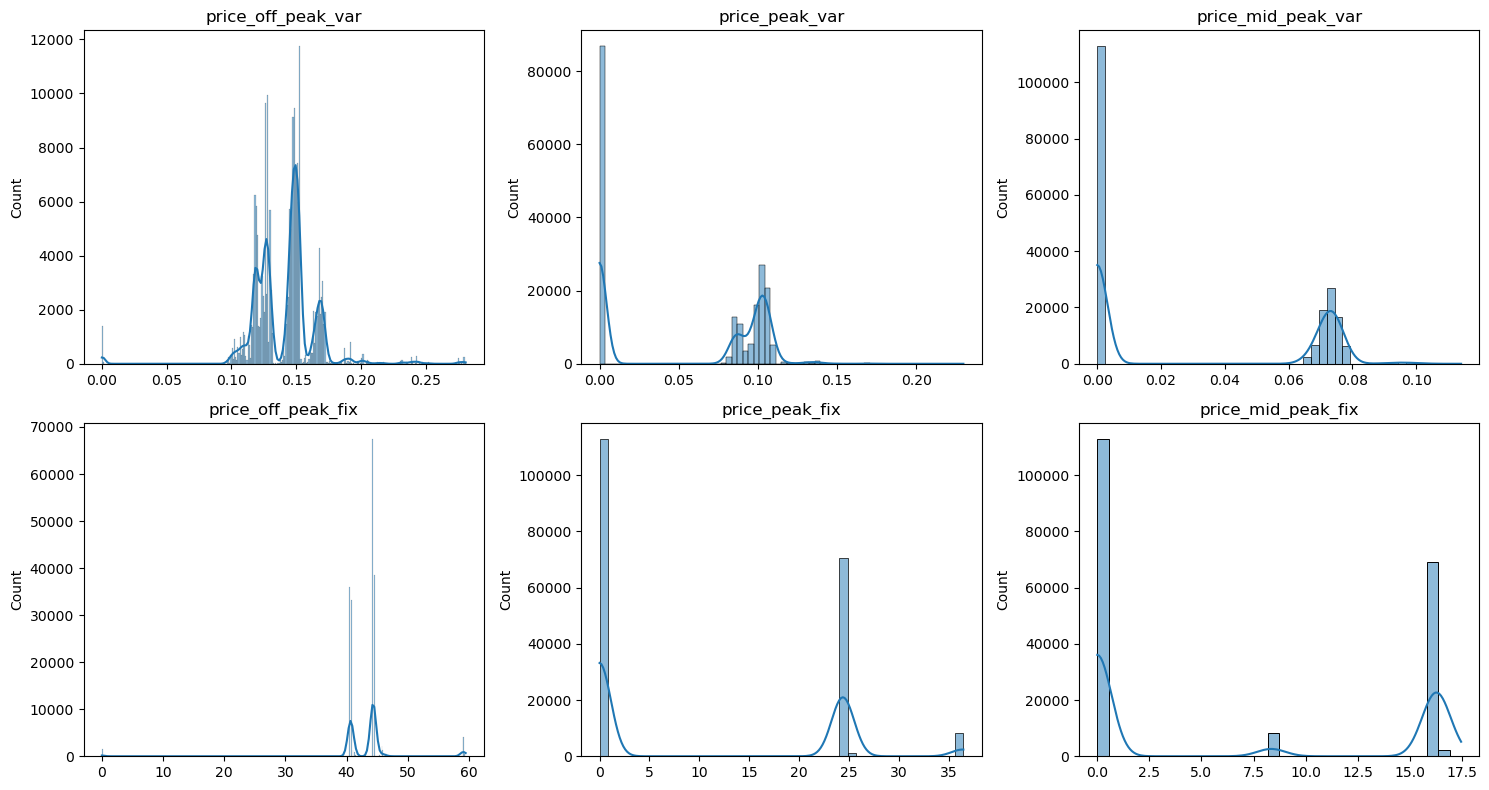

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, column in zip(axes.flatten(), price_numeric_columns):
    sns.histplot(price_df[column], kde=True, ax=ax)
    ax.set_title(column)
    ax.set_xlabel("")
    
plt.tight_layout()
plt.show()

### Interpretation

The pricing variables do not follow simple, symmetric distributions.

The variable pricing features show distinct clusters, with some variables
having substantial concentrations near zero and additional clusters at
higher price levels.

The fixed pricing variables also show clear clusters around particular
values rather than a smooth continuous distribution.

These patterns suggest that customers may be exposed to different pricing
structures or tariff configurations. We will investigate the meaning of
these variables further using the Data Description before deciding whether
any values require treatment.

## 26. Checking Missing Values in Price Data

Before using the pricing data for further analysis, we need to verify
whether any columns contain missing values.

This ensures that apparent patterns in the pricing distributions are not
caused by incomplete observations.

In [33]:
price_df.isnull().sum()

id                    0
price_date            0
price_off_peak_var    0
price_peak_var        0
price_mid_peak_var    0
price_off_peak_fix    0
price_peak_fix        0
price_mid_peak_fix    0
dtype: int64

## 27. Reviewing the Data Description

Before finalizing the EDA and beginning feature engineering, we need to
verify the meaning of the dataset variables.

The Data Description provided by the client will be used to understand:
- What each variable represents
- The meaning of categorical values
- The units of numerical variables
- Which variables may be relevant to customer churn

This prevents us from making assumptions about encoded values during
the analysis.

## 28. Standardizing Missing Values

The Data Description indicates that some fields contain unavailable
information. During the EDA, we found the value `"MISSING"` in the
`channel_sales` and `origin_up` columns.

We will convert these placeholder values to standard `NaN` values so that
missing information is represented consistently.

We will retain these customer records rather than deleting them, since
missing categorical information does not make the entire customer record
invalid.

In [34]:
missing_columns = ["channel_sales", "origin_up"]

client_df[missing_columns] = client_df[missing_columns].replace("MISSING", np.nan)

In [35]:
client_df[missing_columns].isnull().sum()

channel_sales    3725
origin_up          64
dtype: int64

## 29. Checking for Duplicate Records

Duplicate records can distort analysis by counting the same customer
information more than once.

We will check for completely duplicated rows in the client dataset before
continuing with the analysis.

In [36]:
client_df.duplicated().sum()

np.int64(0)

## 30. Checking Duplicate Customer IDs

The previous check found no completely duplicated rows.

However, because `id` represents the client company identifier, we should
also verify whether the same customer appears more than once in the client
dataset.

This is different from checking for duplicate rows because two records can
have the same customer ID while containing different values.

In [37]:
client_df["id"].duplicated().sum()

np.int64(0)

## 31. Checking Duplicate Customer-Date Records in Price Data

The price dataset contains multiple records for each customer because
pricing information is recorded over time.

We will check whether any customer has more than one record for the same
`price_date`.

Duplicate customer-date combinations could indicate duplicated pricing
records and may affect later analysis.

In [38]:
price_df.duplicated(subset=["id", "price_date"]).sum()

np.int64(0)

## 32. Checking Missing Dates After Conversion

The date columns have been converted from text to datetime format.

We will now check whether any invalid date values became missing
(`NaT`) during the conversion.

In [39]:
client_df[date_columns].isnull().sum()

date_activ         0
date_end           0
date_modif_prod    0
date_renewal       0
dtype: int64

## 33. Validating the Churn Target

The `churn` variable is the target used to indicate whether a customer
churned.

According to the Data Description, it represents whether the client
churned over the following three months.

We will verify that the column contains only the expected binary values:
- `0` → did not churn
- `1` → churned

In [40]:
client_df["churn"].unique()

array([1, 0])

## 34. Checking for Negative Values

Some numerical variables, such as consumption and customer counts, should
not contain negative values.

We will check the numerical features for negative observations to identify
any potential data-quality issues.

Negative values will only be treated as errors if they are inconsistent
with the meaning of the variable.

In [41]:
(client_df[numeric_features] < 0).sum()

cons_12m                          0
cons_gas_12m                      0
cons_last_month                   0
forecast_cons_12m                 0
forecast_cons_year                0
forecast_discount_energy          0
forecast_meter_rent_12m           0
forecast_price_energy_off_peak    0
forecast_price_energy_peak        0
forecast_price_pow_off_peak       0
imp_cons                          0
margin_gross_pow_ele              0
margin_net_pow_ele                0
nb_prod_act                       0
net_margin                        0
num_years_antig                   0
pow_max                           0
dtype: int64

## 35. Data Cleaning Summary

The data-quality checks performed during this analysis produced the
following results:

- No completely duplicated rows were found in the client dataset.
- No duplicate customer IDs were found in the client dataset.
- No duplicate customer-date combinations were found in the price dataset.
- No standard missing values were found in the original datasets.
- `"MISSING"` placeholders in `channel_sales` and `origin_up` were
  standardized to `NaN`, while the affected records were retained.
- All customer date columns were converted to datetime format.
- The `price_date` column was converted to datetime format.
- No missing dates were created during date conversion.
- The `churn` variable contains only the expected binary values, 0 and 1.
- No negative values were found in the numerical customer features.
- Potentially extreme values were identified during EDA but were retained,
  as they may represent legitimate customer behavior.

The datasets are now cleaned and structured for the next stage of the
analysis.

## 36. Churn by Sales Channel

The sales channel may influence customer churn because different acquisition
channels can attract customers with different characteristics or expectations.

We will compare the churn status across sales channels to identify whether
some channels have noticeably different churn patterns.

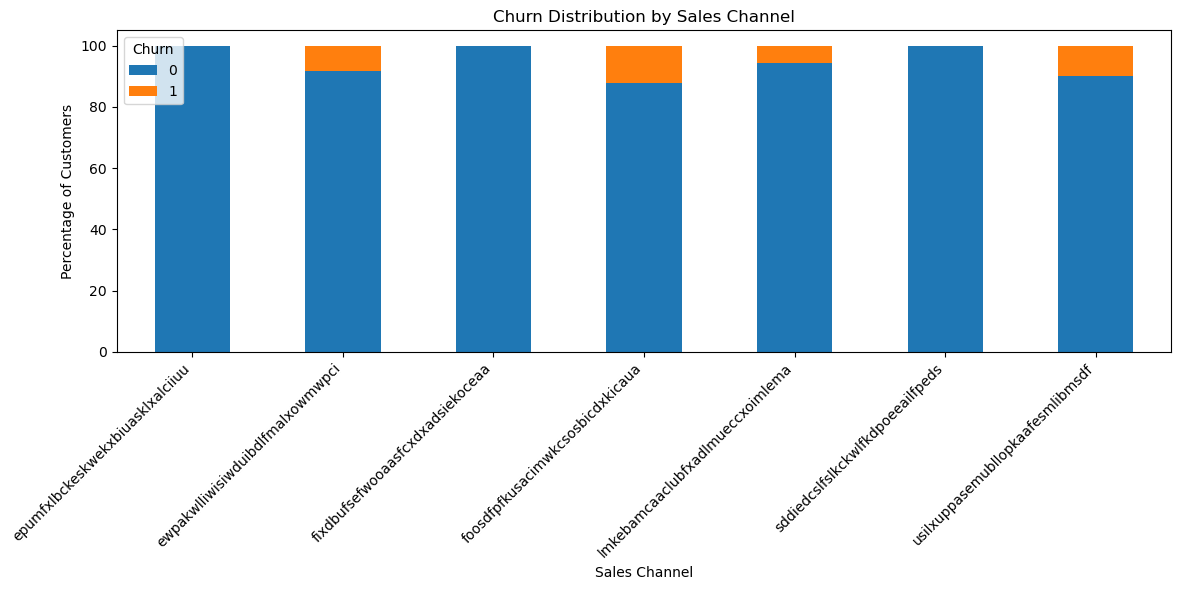

In [42]:
churn_by_channel = pd.crosstab(
    client_df["channel_sales"],
    client_df["churn"],
    normalize="index"
) * 100

churn_by_channel.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Churn Distribution by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

### Interpretation

The churn distribution varies across sales channels.

Most sales channels have a relatively low proportion of churned customers,
but some channels show a noticeably higher churn proportion than others.
This suggests that sales channel may be associated with differences in
customer churn.

However, some channels contain very few customers, so their observed churn
rates may not be reliable enough to draw strong conclusions.

The `"MISSING"` sales-channel values were retained as missing values during
cleaning and are not included in this visualization.

## 37. Churn by Number of Products

The `nb_prod_act` variable represents the number of active products
associated with a customer.

We will compare churn across different numbers of active products to
identify whether customers with different product counts show different
churn patterns.

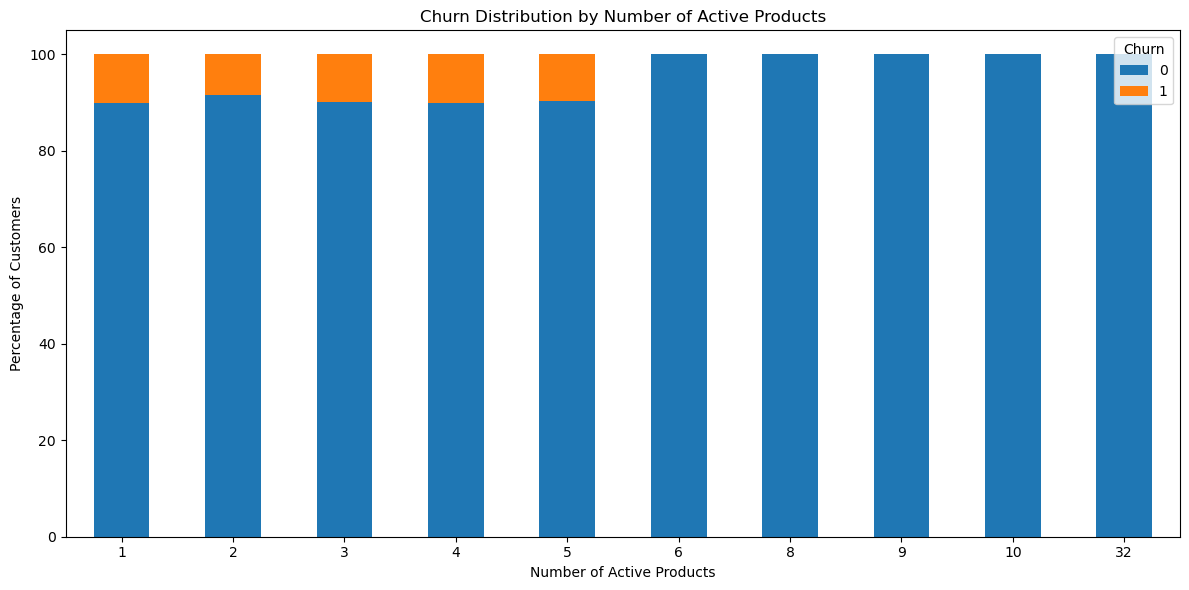

In [43]:
churn_by_products = pd.crosstab(
    client_df["nb_prod_act"],
    client_df["churn"],
    normalize="index"
) * 100

churn_by_products.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Churn Distribution by Number of Active Products")
plt.xlabel("Number of Active Products")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

### Interpretation

The distribution shows that churn is concentrated among customers with a
smaller number of active products.

Customers with 1 to 5 active products show a visible proportion of churn,
while the groups with higher numbers of active products show little or no
observed churn in this dataset.

However, some of the higher-product groups may contain relatively few
customers. Therefore, their low observed churn rates should be interpreted
with caution.

Overall, the analysis suggests that the number of active products may be
associated with customer churn and is worth considering in further analysis.

## 38. Churn by Customer Tenure

The `num_years_antig` variable represents the number of years the customer
has been with PowerCo.

We will compare churn across different customer-tenure groups to investigate
whether the length of the customer relationship is associated with churn.

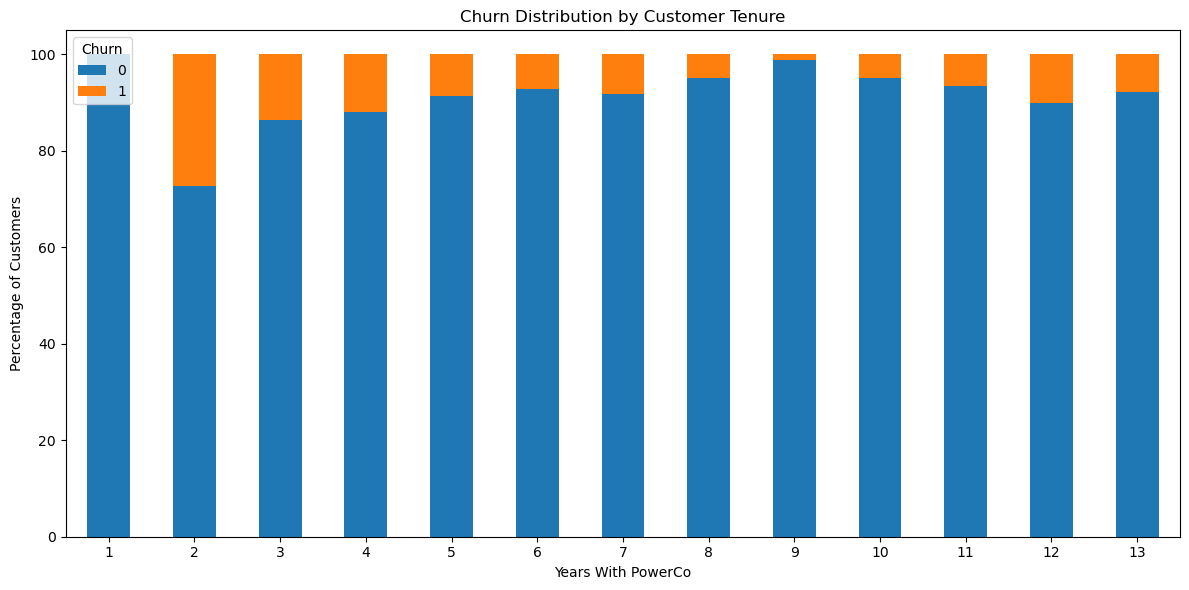

In [44]:
churn_by_tenure = pd.crosstab(
    client_df["num_years_antig"],
    client_df["churn"],
    normalize="index"
) * 100

churn_by_tenure.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Churn Distribution by Customer Tenure")
plt.xlabel("Years With PowerCo")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

### Interpretation

The churn distribution varies across customer-tenure groups.

Customers with around 2 to 5 years of tenure show relatively higher
proportions of churn, while many of the longer-tenured groups show lower
churn proportions.

The relationship is not perfectly consistent across all tenure levels,
but the overall pattern suggests that customer tenure may be associated
with churn.

This variable should therefore be considered in further analysis, while
recognizing that the observed relationship does not imply that tenure
itself causes churn.

## 39. Churn by Customer Origin

The `origin_up` variable represents the code of the electricity campaign
through which the customer was first subscribed.

We will compare churn across different customer-origin groups to investigate
whether the initial acquisition campaign is associated with customer churn.

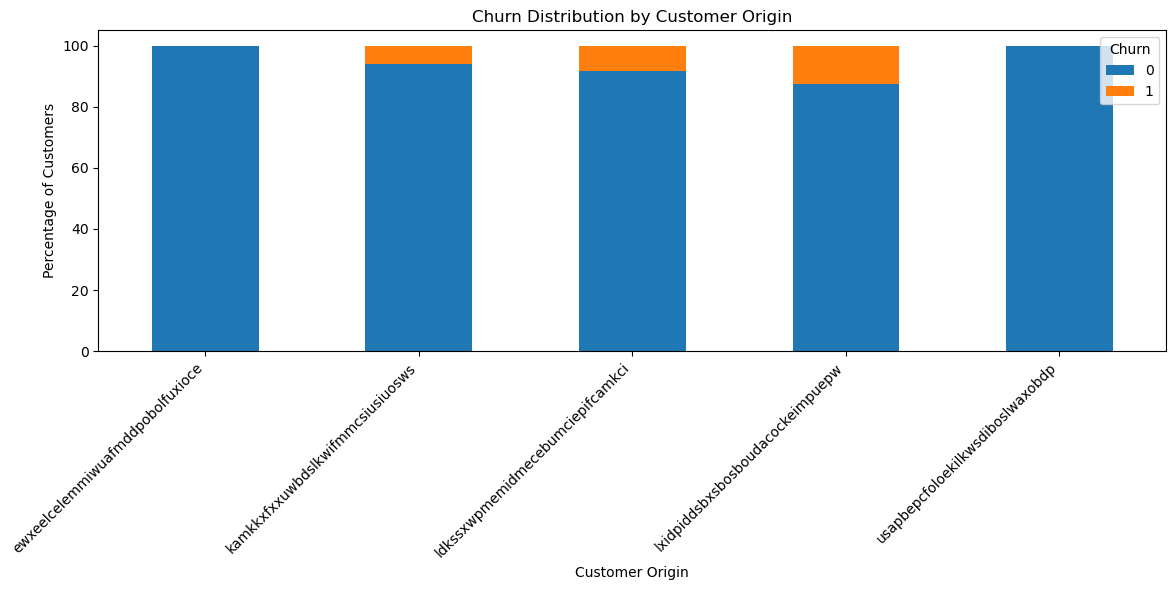

In [45]:
churn_by_origin = pd.crosstab(
    client_df["origin_up"],
    client_df["churn"],
    normalize="index"
) * 100

churn_by_origin.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Churn Distribution by Customer Origin")
plt.xlabel("Customer Origin")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

### Interpretation

The churn distribution varies across customer-origin groups.

The main customer-origin groups show different proportions of churn, with
some origins having noticeably higher churn than others.

The two very rare origin categories show no observed churn, but their sample
sizes are extremely small, so these results should not be treated as
representative.

Overall, customer origin appears to be associated with differences in churn
and may be useful for further analysis.

## 40. Distribution of Customer Consumption

The consumption variables describe the customer's electricity and gas
consumption over different periods.

We will examine their distributions to identify:
- The typical range of consumption
- Skewness
- Potential extreme values
- Differences between recent and forecast consumption

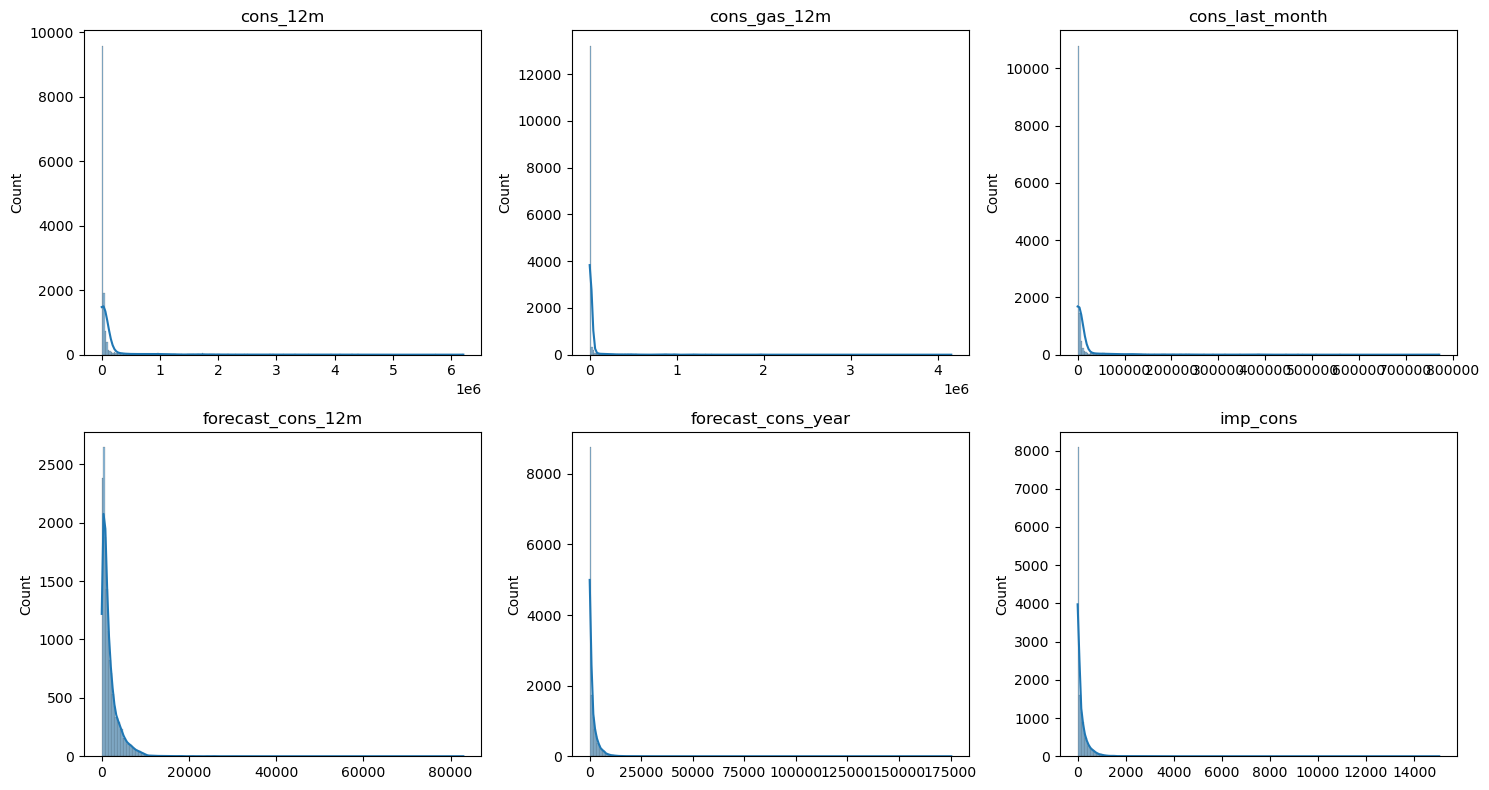

In [46]:
consumption_features = [
    "cons_12m",
    "cons_gas_12m",
    "cons_last_month",
    "forecast_cons_12m",
    "forecast_cons_year",
    "imp_cons"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, column in zip(axes.flatten(), consumption_features):
    sns.histplot(client_df[column], kde=True, ax=ax)
    ax.set_title(column)
    ax.set_xlabel("")
    
plt.tight_layout()
plt.show()

### Interpretation

All six consumption variables show a strong positive (right) skew.

Most customers have relatively low consumption values, while a smaller
number of customers have substantially higher consumption, creating long
right-hand tails.

This indicates that extreme observations are present in the consumption
variables and should be investigated further.

The strong skewness may also need to be considered during feature
engineering, where transformations could potentially be used to make the
distributions more suitable for analysis or modelling.

## 41. Investigating Consumption Outliers

The histograms showed strong positive skewness and long right tails in the
consumption variables.

We will use boxplots to identify potential outliers more clearly.

A boxplot highlights observations that fall far beyond the typical range
of the data. These observations will be investigated but not automatically
removed, as they may represent legitimate high-consumption customers.

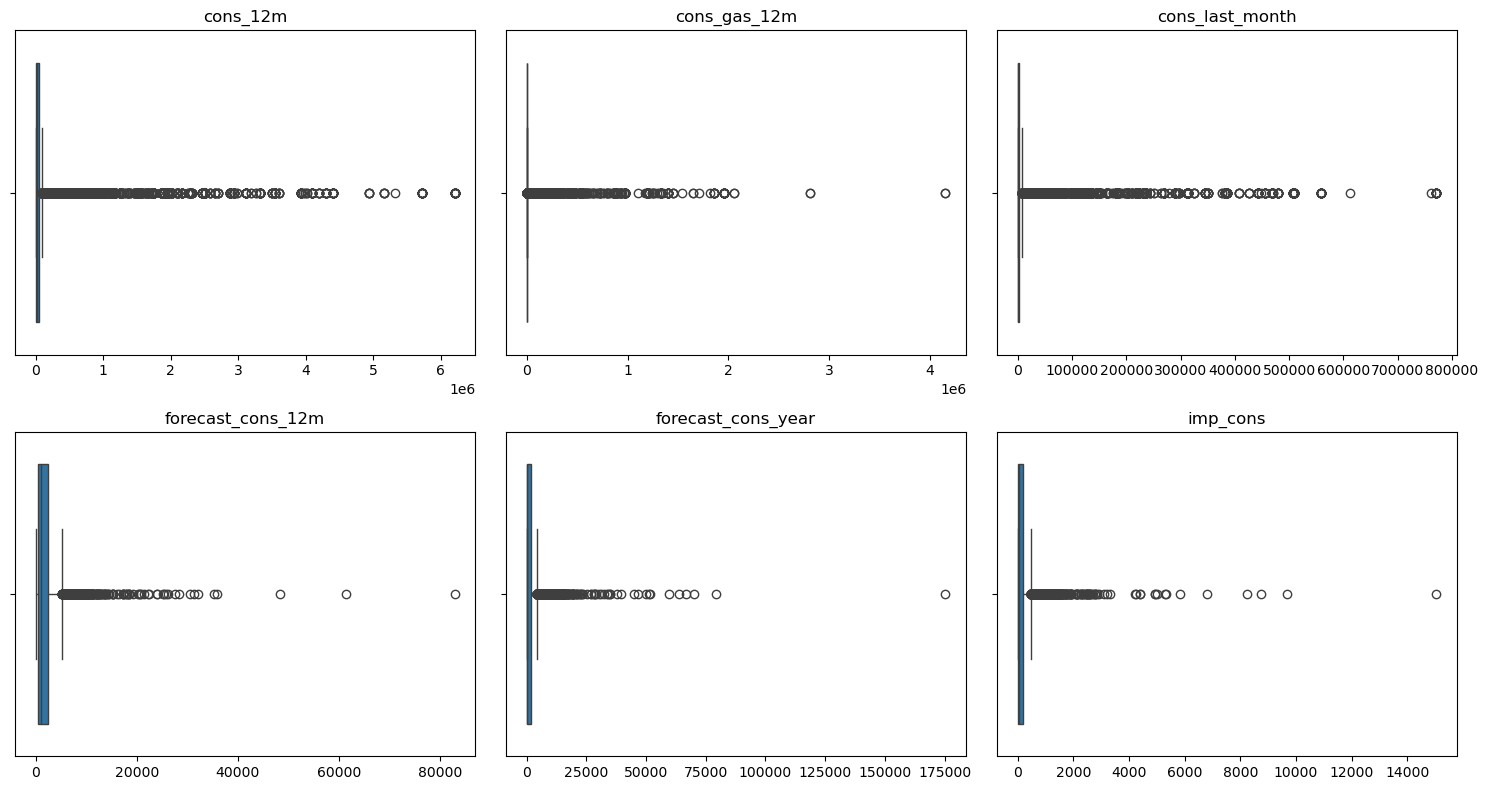

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, column in zip(axes.flatten(), consumption_features):
    sns.boxplot(x=client_df[column], ax=ax)
    ax.set_title(column)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

### Interpretation

The boxplots confirm that the consumption variables contain a substantial
number of potential outliers, particularly on the upper end of their
distributions.

This is consistent with the strong positive skew observed in the
histograms.

These extreme observations should not be removed automatically because they
may represent legitimate customers with unusually high energy consumption.

The presence of skewness and potential outliers should be considered during
feature engineering, where transformations or other appropriate treatment
may be evaluated.

## 42. Distribution of Subscribed Power

The `pow_max` variable represents the subscribed power of the customer.

We will examine its distribution to understand its typical range,
skewness, and potential extreme values.

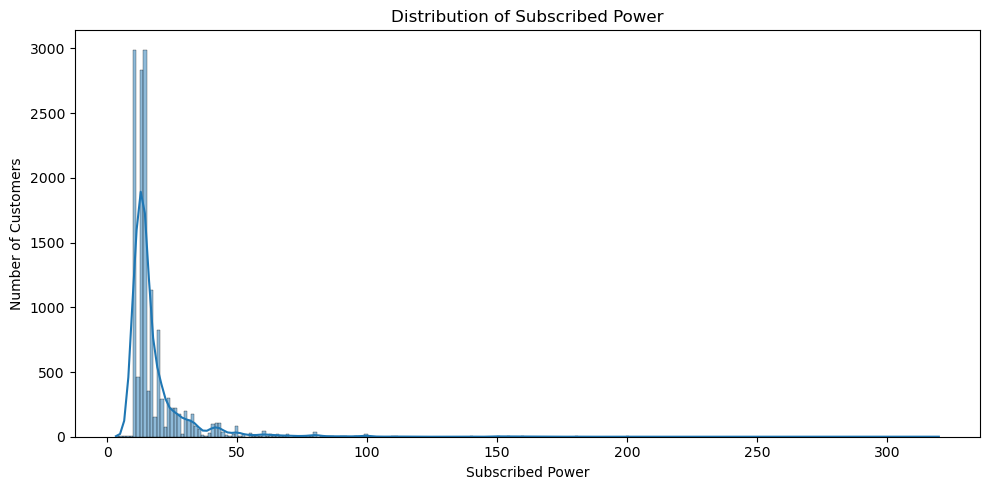

In [48]:
plt.figure(figsize=(10, 5))

sns.histplot(client_df["pow_max"], kde=True)

plt.title("Distribution of Subscribed Power")
plt.xlabel("Subscribed Power")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### Interpretation

The distribution of subscribed power is positively skewed.

Most customers have relatively low subscribed power, while a smaller number
of customers have substantially higher values, creating a long right tail.

This indicates the presence of potential extreme observations in
`pow_max`. These observations will be retained at this stage because they
may represent legitimate customers with higher power requirements.

The skewness and potential outliers can be considered during feature
engineering if further transformation or treatment is appropriate.